In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display

import matplotlib.pyplot as plt
import os

In [15]:
# put all the joined data frames into a dictionary for easy access

joined_dfs = {}

for year in range(2014, 2025):
    df = pd.read_csv(f'../Data/raw_data/{year}/join_df_{year}.csv')
    joined_dfs[year] = df

### Each joined_df is the result of joining Institutional HR, Finance and Header Information

In [16]:
joined_dfs[2014].head()

,UNITID,INSTNM,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,...,SFTEBFO,SFTECES,SFTECLAM,SFTEHLTH,SFTEOTHR,SFTESRVC,SFTESALE,SFTEOFAS,SFTENRCM,SFTEPTMM
0,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,...,35.0,36.0,124.0,1.0,NaN,54.0,3.0,173.0,9.0,13.0
1,100663,University of Alabama at Birmingham,Administration Bldg Suite 1070,Birmingham,AL,35294-0110,1,5,Ray L. Watts,President,...,1032.0,1360.0,311.0,418.0,NaN,682.0,NaN,1266.0,303.0,85.0
2,100706,University of Alabama in Huntsville,301 Sparkman Dr,Huntsville,AL,35899,1,5,Robert A. Altenkirch,President,...,73.0,469.0,59.0,3.0,NaN,87.0,NaN,190.0,28.0,1.0
3,100724,Alabama State University,915 S Jackson Street,Montgomery,AL,36104-0271,1,5,Gwen Boyd,President,...,38.0,29.0,93.0,4.0,NaN,146.0,8.0,122.0,39.0,9.0
4,100751,The University of Alabama,739 University Blvd,Tuscaloosa,AL,35487-0166,1,5,Dr. Judith L. Bonner,President,...,414.0,434.0,491.0,206.0,NaN,719.0,27.0,849.0,209.0,118.0


### Overall summary across all years

In [17]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Overall summary across all years
summary_rows = []
for year, df in joined_dfs.items():
    summary_rows.append({
        "year": year,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "numeric_cols": df.select_dtypes(include=["number"]).shape[1],
        "categorical_cols": df.select_dtypes(exclude=["number"]).shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("year")
display(summary_df)

,year,rows,columns,numeric_cols,categorical_cols,missing_cells,duplicate_rows
0,2014,725,416,237,179,28287,0
1,2015,734,426,243,183,29994,0
2,2016,759,316,188,128,24789,0
3,2017,775,316,187,129,26220,0
4,2018,796,317,187,130,29911,0
5,2019,807,325,191,134,31096,0
6,2020,806,386,223,163,33403,0
7,2021,784,387,217,170,13193,0
8,2022,814,386,216,170,20169,0
9,2023,822,386,224,162,20668,0


### EDA per Year

In [18]:
# Per-year EDA
for year, df in joined_dfs.items():
    print(f"\n{'=' * 70}")
    print(f"EDA for {year}")
    print(f"Shape: {df.shape}")
    print("Data types:")
    print(df.dtypes.astype(str))

    # Missing values
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    if not missing.empty:
        print("\nMissing values (top 10 columns):")
        display(missing.head(10))

    # Numeric summary and histograms
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if num_cols:
        print("\nNumeric column summary:")
        display(df[num_cols].describe().T)

    # Categorical value counts
    cat_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
    if cat_cols:
        print("\nTop values for categorical columns:")
        for col in cat_cols[:5]:
            counts = df[col].value_counts(dropna=False).head(10)
            if not counts.empty:
                print(f"\n{col}:")
                print(counts)


EDA for 2014
Shape: (725, 416)
Data types:
UNITID        int64
INSTNM       object
ADDR         object
CITY         object
STABBR       object
             ...   
SFTESRVC    float64
SFTESALE    float64
SFTEOFAS    float64
SFTENRCM    float64
SFTEPTMM    float64
Length: 416, dtype: object

Missing values (top 10 columns):


SALPROF     725
SALASSC     725
SFTEOTHR    725
SALTOTL     725
SFTEOTIS    725
SFTELCA     725
SFTELCAI    725
SFTEPSTC    725
SALNRNK     725
SALLECT     725
dtype: int64


Numeric column summary:


,count,mean,std,min,25%,50%,75%,max
UNITID,725.0,1.965031e+05,6.989169e+04,100654.0,155025.0,196033.0,220862.0,484905.0
FIPS,725.0,3.106759e+01,1.663484e+01,1.0,17.0,34.0,42.0,78.0
OBEREG,725.0,4.507586e+00,2.171897e+00,0.0,3.0,5.0,6.0,9.0
EIN,725.0,5.151423e+08,2.601507e+08,-1.0,316402079.0,556000822.0,726000848.0,996000354.0
OPEID,725.0,4.415575e+05,6.033862e+05,-2.0,194900.0,295000.0,369800.0,4229500.0
...,...,...,...,...,...,...,...,...
SFTESRVC,701.0,1.646320e+02,2.805309e+02,0.0,32.0,75.0,166.0,3536.0
SFTESALE,312.0,7.503205e+00,1.276072e+01,0.0,1.0,3.0,8.0,96.0
SFTEOFAS,715.0,2.660573e+02,3.859198e+02,1.0,57.0,123.0,282.5,2715.0
SFTENRCM,677.0,7.005613e+01,1.071103e+02,0.0,12.0,31.0,72.0,690.0



Top values for categorical columns:

INSTNM:
INSTNM
Alabama A & M University                                            1
California University of Pennsylvania                               1
Clarion University of Pennsylvania                                  1
The Dickinson School of Law of the Pennsylvania State University    1
East Stroudsburg University of Pennsylvania                         1
Edinboro University of Pennsylvania                                 1
Indiana University of Pennsylvania-Main Campus                      1
Kutztown University of Pennsylvania                                 1
The Lincoln University                                              1
Lock Haven University                                               1
Name: count, dtype: int64

ADDR:
ADDR
                        5
One University Plaza    2
One University Place    2
300 Campus Drive        2
1 University Circle     2
1 Main Street           2
4900 Meridian Street    1
15200 Kutztown Rd       1
8

...


Top values for categorical columns:

INSTNM:
INSTNM
Lincoln University                                            2
Alabama A & M University                                      1
University of Pittsburgh-Bradford                             1
Pennsylvania State University-Penn State Brandywine           1
Pennsylvania State University-Penn State DuBois               1
Pennsylvania State University-Penn State Fayette- Eberly      1
Pennsylvania State University-Penn State Hazleton             1
Pennsylvania State University-Main Campus                     1
Pennsylvania State University-Penn State Greater Allegheny    1
Pennsylvania State University-Penn State Mont Alto            1
Name: count, dtype: int64

IALIAS:
IALIAS
NaN        353
WSU          3
BC           3
ECU          2
Western      2
GHC          2
MSU          2
ISU          2
NSU          2
K-State      2
Name: count, dtype: int64

ADDR:
ADDR
NaN                     4
One University Drive    2
One University Plaza    2

SALNRNK    542
SALLECT    444
IALIAS     368
ATHURL     351
F1M07      291
F1M05      291
F1M06      291
F1M08      291
F1M02      261
F1M01      261
dtype: int64


Numeric column summary:


,count,mean,std,min,25%,50%,75%,max
UNITID,848.0,1.993884e+05,7.706048e+04,1.006540e+05,1.513195e+05,1.961535e+05,2.265075e+05,4.985710e+05
FIPS,848.0,3.112028e+01,1.726793e+01,1.000000e+00,1.300000e+01,3.500000e+01,4.500000e+01,7.800000e+01
OBEREG,848.0,4.810142e+00,2.209893e+00,0.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00,9.000000e+00
GENTELE,848.0,1.388826e+12,1.121376e+13,2.012002e+09,4.025581e+09,6.071098e+09,8.072296e+09,2.078348e+14
EIN,848.0,5.523155e+08,2.620947e+08,3.414000e+06,3.560017e+08,5.809527e+08,7.511806e+08,9.960004e+08
...,...,...,...,...,...,...,...,...
SFTESRVC,847.0,1.452186e+02,2.964791e+02,0.000000e+00,2.267000e+01,5.467000e+01,1.401650e+02,3.985330e+03
SFTESALE,847.0,2.523223e+00,8.786983e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.426700e+02
SFTEOFAS,847.0,2.068053e+02,3.724254e+02,3.700000e-01,3.681500e+01,8.767000e+01,1.921650e+02,4.452330e+03
SFTENRCM,847.0,5.466766e+01,9.940467e+01,0.000000e+00,6.330000e+00,1.900000e+01,5.283500e+01,7.406700e+02



Top values for categorical columns:

INSTNM:
INSTNM
Lincoln University                                          2
Alabama A & M University                                    1
Pennsylvania State University-Penn State Beaver             1
Pennsylvania State University-Penn State Berks              1
Pennsylvania State University-Penn State Harrisburg         1
Pennsylvania State University-Penn State Brandywine         1
Pennsylvania State University-Penn State DuBois             1
Pennsylvania State University-Penn State Fayette- Eberly    1
Pennsylvania State University-Penn State Hazleton           1
Pennsylvania State University-Main Campus                   1
Name: count, dtype: int64

IALIAS:
IALIAS
NaN        368
WSU          3
BC           3
MSU          2
GHC          2
ECU          2
K-State      2
NSU          2
Western      2
HCC          2
Name: count, dtype: int64

ADDR:
ADDR
NaN                     5
One University Drive    2
1 University Circle     2
300 Campus Drive   

### Check for repeated information in each yearly joined dataframe

In [19]:
dup_summary = []

for year, df in joined_dfs.items():
    # Exact duplicate rows across all columns
    row_dup_count = int(df.duplicated().sum())

    # Duplicate UNITID values
    unitid_dup_count = 0
    if "UNITID" in df.columns:
        unitid_series = df["UNITID"].dropna()
        unitid_dup_count = int(unitid_series.duplicated().sum()) if not unitid_series.empty else 0

    # Duplicate column names
    col_dup_count = int(df.columns.duplicated().sum())

    dup_summary.append({
        "year": year,
        "duplicate_rows": row_dup_count,
        "duplicate_UNITID_values": unitid_dup_count,
        "duplicate_column_names": col_dup_count,
    })

dup_summary_df = pd.DataFrame(dup_summary).sort_values("year")
display(dup_summary_df)

# Print any duplicated rows if present
for year, df in joined_dfs.items():
    dup_rows = df[df.duplicated(keep=False)]
    if not dup_rows.empty:
        print(f"\nRepeated rows found for {year}:")
        display(dup_rows.head(10))

# Final summary message
if (dup_summary_df["duplicate_rows"] > 0).any() or (dup_summary_df["duplicate_UNITID_values"] > 0).any() or (dup_summary_df["duplicate_column_names"] > 0).any():
    print("\nRepeated information was found in at least one year.")
else:
    print("\nNo repeated information was found in any year.")

,year,duplicate_rows,duplicate_UNITID_values,duplicate_column_names
0,2014,0,0,0
1,2015,0,0,0
2,2016,0,0,0
3,2017,0,0,0
4,2018,0,0,0
5,2019,0,0,0
6,2020,0,0,0
7,2021,0,0,0
8,2022,0,0,0
9,2023,0,0,0



No repeated information was found in any year.


### Reloaded the dasets and added a year feature. 

In [20]:
joined_dfs = []

# ---------------------------------------------------------
# 1. LOAD AND STACK ALL YEARLY DATA (2014-2024)
# ---------------------------------------------------------
for year in range(2014, 2025):
    file_path = f'../Data/raw_data/{year}/join_df_{year}.csv'
    
    if os.path.exists(file_path):
        # Load the data for the specific year
        df = pd.read_csv(file_path)
        
        # Add a 'YEAR' column to track the timeline
        df['YEAR'] = year
        
        joined_dfs.append(df)
        print(f"[+] Successfully loaded data for {year} (Rows: {len(df)})")
    else:
        print(f"[-] File for {year} not found. Skipping...")

# Concatenate all the dataframes vertically into one master dataframe
master_panel_df = pd.concat(joined_dfs, ignore_index=True)
print(f"\n[+] Master Panel Created. Total Rows: {len(master_panel_df)}")

[+] Successfully loaded data for 2014 (Rows: 725)
[+] Successfully loaded data for 2015 (Rows: 734)
[+] Successfully loaded data for 2016 (Rows: 759)
[+] Successfully loaded data for 2017 (Rows: 775)
[+] Successfully loaded data for 2018 (Rows: 796)
[+] Successfully loaded data for 2019 (Rows: 807)
[+] Successfully loaded data for 2020 (Rows: 806)
[+] Successfully loaded data for 2021 (Rows: 784)
[+] Successfully loaded data for 2022 (Rows: 814)
[+] Successfully loaded data for 2023 (Rows: 822)
[+] Successfully loaded data for 2024 (Rows: 848)

[+] Master Panel Created. Total Rows: 8670


### Feature Engineering binary target feature (AI-Assisted)

In [21]:
# ---------------------------------------------------------
# 2. CALCULATE YEAR-OVER-YEAR (YoY) CHANGES FOR TOTAL STAFF
# ---------------------------------------------------------
# Crucial: Sort by university ID and then chronologically by year 
# so the math calculates in the correct order
master_panel_df = master_panel_df.sort_values(by=['UNITID', 'YEAR'])

# Calculate the raw YoY change in Total FTE Staff
# (Current Year - Previous Year)
master_panel_df['FTE_TOTL_YOY_CHANGE'] = master_panel_df.groupby('UNITID')['SFTETOTL'].diff()

# Calculate the percentage change in Total Staff 
# (Highly recommended for ML: it normalizes layoffs between massive universities and small colleges)
master_panel_df['FTE_TOTL_PCT_CHANGE'] = (
    master_panel_df['FTE_TOTL_YOY_CHANGE'] / master_panel_df.groupby('UNITID')['SFTETOTL'].shift(1)
) * 100

# ---------------------------------------------------------
# 3. DEFINE YOUR MACHINE LEARNING TARGET
# ---------------------------------------------------------
# Create the binary target variable based on TOTAL staff losses
# 1 = Vulnerable (Lost total staff), 0 = Stable (Maintained or gained staff)
master_panel_df['TARGET_VULNERABLE_TOTAL'] = (master_panel_df['FTE_TOTL_YOY_CHANGE'] < 0).astype(int)

# ---------------------------------------------------------
# 4. REVIEW AND SAVE
# ---------------------------------------------------------
print("\nSample of the newly calculated Total Staff YoY features:")
print(master_panel_df[['UNITID', 'YEAR', 'SFTETOTL', 'FTE_TOTL_YOY_CHANGE', 'FTE_TOTL_PCT_CHANGE', 'TARGET_VULNERABLE_TOTAL']].head(10))


Sample of the newly calculated Total Staff YoY features:
      UNITID  YEAR  SFTETOTL  FTE_TOTL_YOY_CHANGE  FTE_TOTL_PCT_CHANGE  \
0     100654  2014     794.0                  NaN                  NaN   
725   100654  2015     832.0                 38.0             4.785894   
1459  100654  2016     846.0                 14.0             1.682692   
2218  100654  2017     861.0                 15.0             1.773050   
2993  100654  2018     855.0                 -6.0            -0.696864   
3789  100654  2019     800.0                -55.0            -6.432749   
4596  100654  2020     814.0                 14.0             1.750000   
5402  100654  2021     689.0               -125.0           -15.356265   
6186  100654  2022     817.0                128.0            18.577649   
7000  100654  2023     852.0                 35.0             4.283966   

      TARGET_VULNERABLE_TOTAL  
0                           0  
725                         0  
1459                        0  

/var/folders/jh/9ry3rwr171745zlhrlbbzww80000gn/T/ipykernel_9478/3605105237.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_panel_df['FTE_TOTL_YOY_CHANGE'] = master_panel_df.groupby('UNITID')['SFTETOTL'].diff()
/var/folders/jh/9ry3rwr171745zlhrlbbzww80000gn/T/ipykernel_9478/3605105237.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_panel_df['FTE_TOTL_PCT_CHANGE'] = (
/var/folders/jh/9ry3rwr171745zlhrlbbzww80000gn/T/ipykernel_9478/3605105237.py:23: PerformanceWarning: DataFrame is highly fragmented.  This i

### Initial overview (ALL YEARS COMBINED)

In [30]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1) Basic overview
print("Shape of master_panel_df:", master_panel_df.shape)
display(master_panel_df.head(3))

Shape of master_panel_df: (8670, 542)


,UNITID,INSTNM,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,...,CARNEGIEIC,CARNEGIESAEC,CARNEGIERSCH,CARNEGIESIZE,CARNEGIEALF,CARNEGIEAPM,CARNEGIEGPM,FTE_TOTL_YOY_CHANGE,FTE_TOTL_PCT_CHANGE,TARGET_VULNERABLE_TOTAL
0,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
725,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,4.785894,0
1459,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,1.682692,0


In [31]:
numeric_cols = master_panel_df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = master_panel_df.select_dtypes(exclude=["number"]).columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical/object columns: {len(cat_cols)}")

Numeric columns: 308
Categorical/object columns: 234


### Top columns missing values


Top missing columns:


CCUGPROF        7945
CCIPUG          7945
CCSIZSET        7945
CCENRPRF        7945
CCIPGRAD        7945
CARNEGIERSCH    7822
CARNEGIEAPM     7822
CARNEGIEALF     7822
C00CARNEGIE     7822
CARNEGIEIC      7822
CARNEGIESIZE    7822
CARNEGIESAEC    7822
CARNEGIEGPM     7822
F1C134          7315
F1C133          7315
F1C125          7315
F1C123          7315
F1C127          7315
F1C137          7315
F1C136          7315
dtype: int64

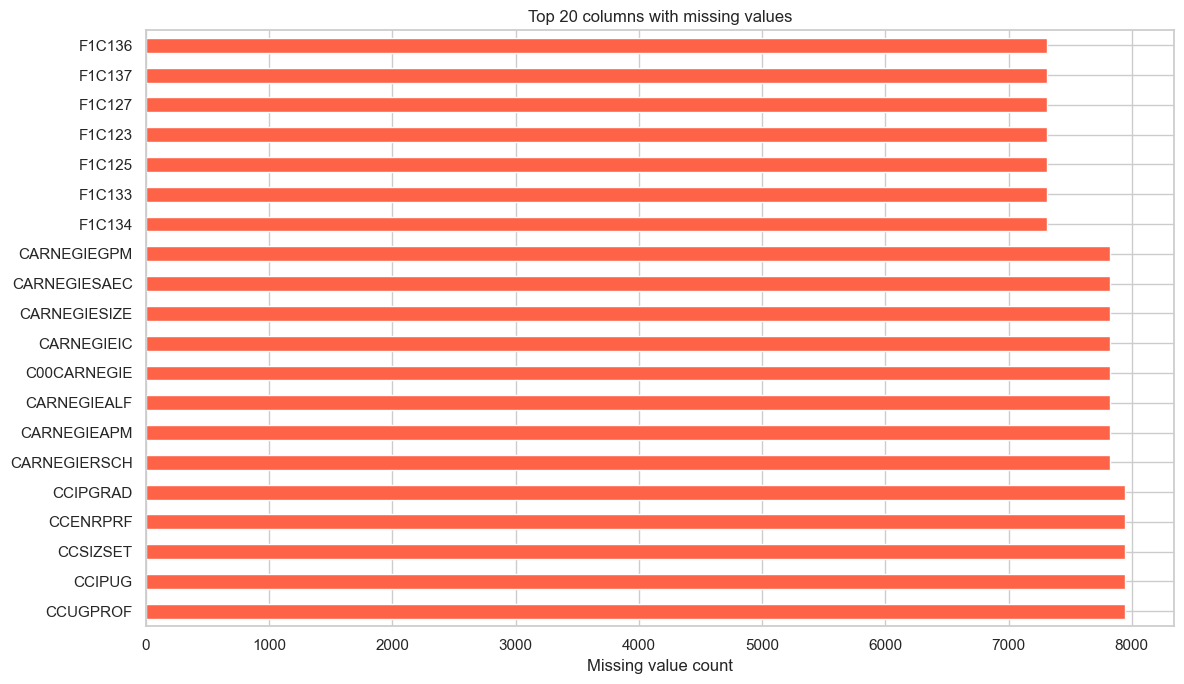

In [32]:
missing_summary = master_panel_df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print("\nTop missing columns:")
display(missing_summary.head(20))

plt.figure(figsize=(12, 7))
missing_summary.head(20).plot(kind="barh", color="tomato")
plt.title("Top 20 columns with missing values")
plt.xlabel("Missing value count")
plt.tight_layout()
plt.show()

### Records per year

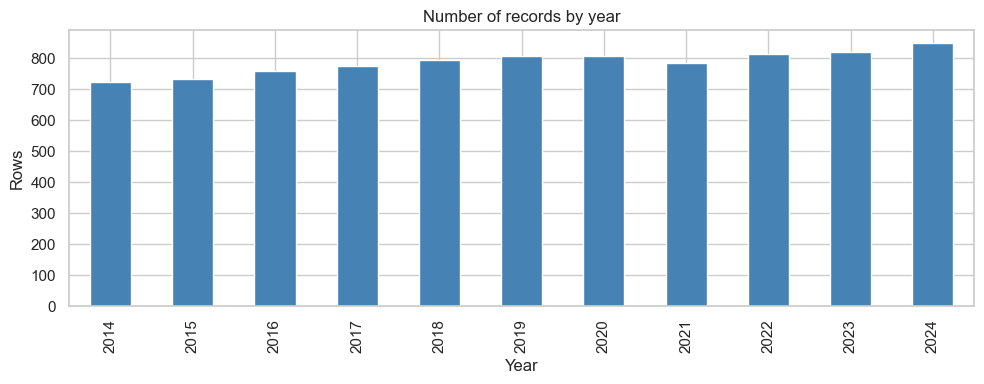

In [33]:
year_counts = master_panel_df["YEAR"].value_counts().sort_index()
plt.figure(figsize=(10, 4))
year_counts.plot(kind="bar", color="steelblue")
plt.title("Number of records by year")
plt.xlabel("Year")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

### Target Feature

/var/folders/jh/9ry3rwr171745zlhrlbbzww80000gn/T/ipykernel_9478/3400126286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_panel_df, x="TARGET_VULNERABLE_TOTAL", palette="Set2")


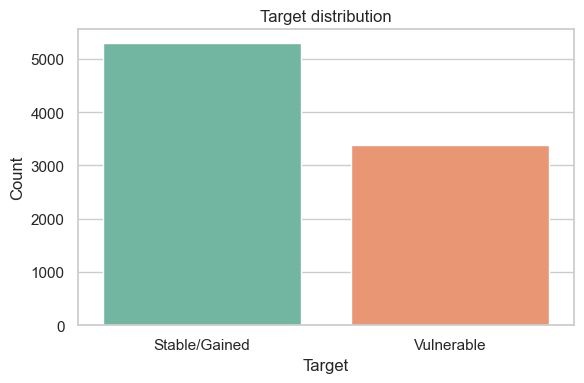

In [34]:
target_counts = master_panel_df["TARGET_VULNERABLE_TOTAL"].value_counts().sort_index()
target_labels = {0: "Stable/Gained", 1: "Vulnerable"}
plt.figure(figsize=(6, 4))
sns.countplot(data=master_panel_df, x="TARGET_VULNERABLE_TOTAL", palette="Set2")
plt.xticks(ticks=[0, 1], labels=[target_labels.get(0, "Stable/Gained"), target_labels.get(1, "Vulnerable")])
plt.title("Target distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Some Staffing Columns

In [35]:
staff_cols = [c for c in ["SFTETOTL", "SALTOTL", "SFTEINST", "SFTEPSTC", "SFTESRVC", "SALPROF", "SALASSC"] if c in master_panel_df.columns]
print("\nStaffing columns used for EDA:", staff_cols)

display(master_panel_df[staff_cols].describe().T)


Staffing columns used for EDA: ['SFTETOTL', 'SALTOTL', 'SFTEINST', 'SFTEPSTC', 'SFTESRVC', 'SALPROF', 'SALASSC']


,count,mean,std,min,25%,50%,75%,max
SFTETOTL,8514.0,1945.374009,3186.009184,0.0,384.0,825.00,1883.50,35878.68
SFTEINST,8503.0,592.690844,767.580577,0.0,150.0,327.00,720.00,7851.33
SFTEPSTC,3250.0,682.498803,1047.930434,0.0,145.0,317.67,736.75,8786.67
SFTESRVC,8350.0,154.212231,279.256595,0.0,27.0,64.00,155.00,3985.33


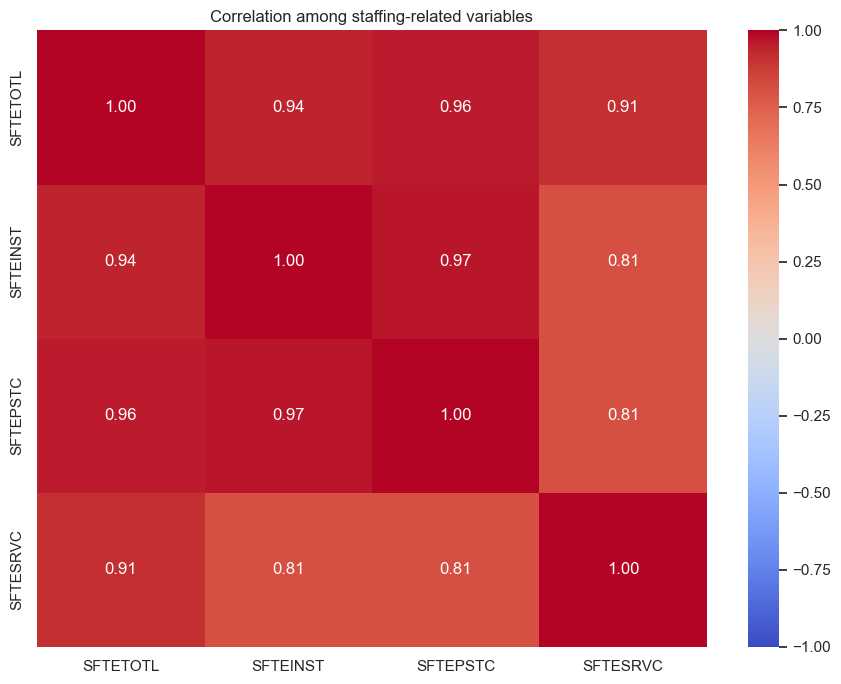

In [36]:
corr = master_panel_df[staff_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation among staffing-related variables")
plt.tight_layout()
plt.show()

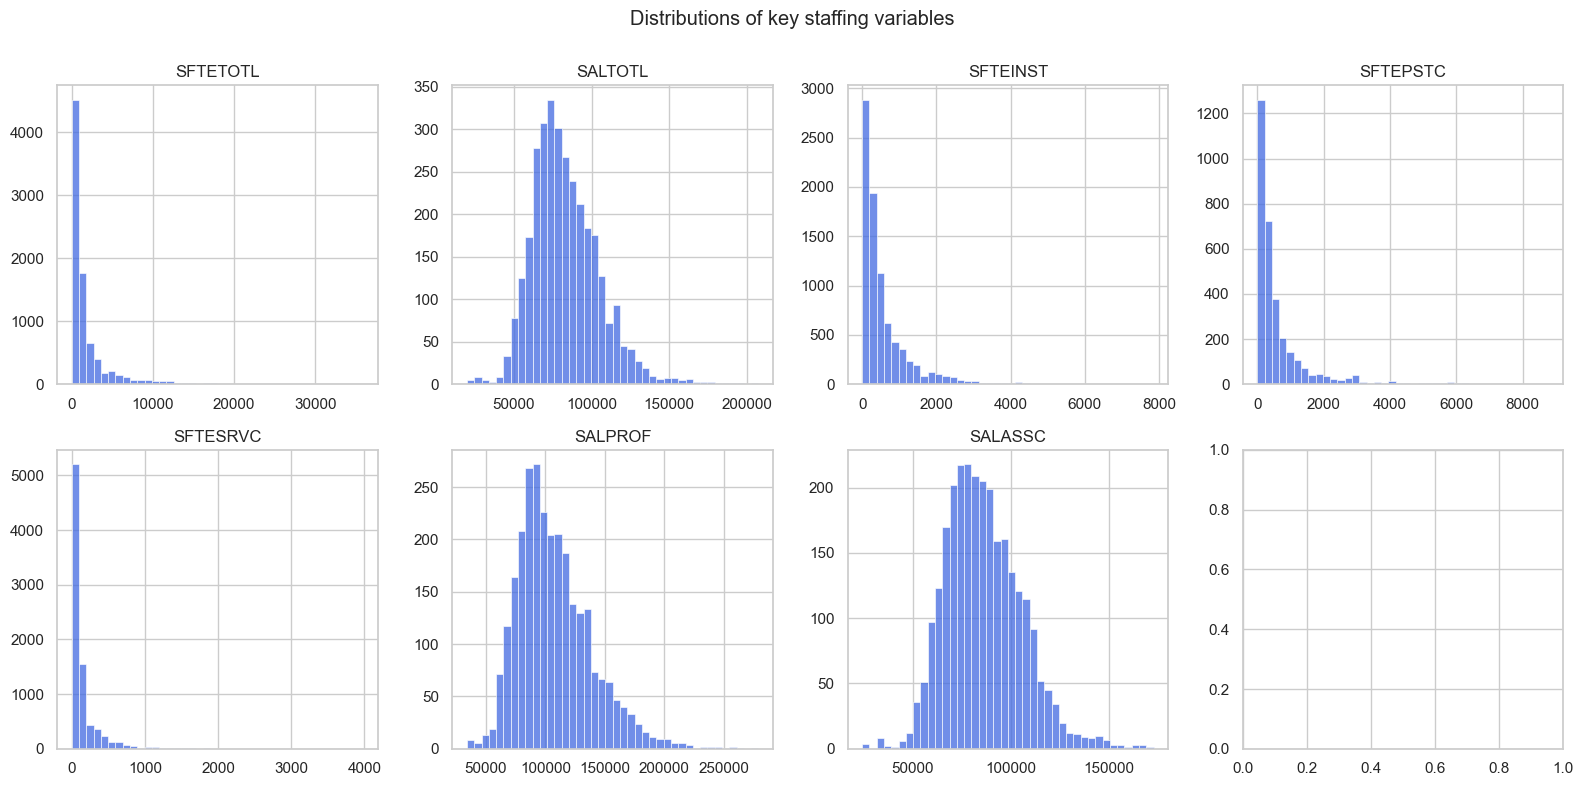

In [39]:
# 9) Distribution of staffing variables
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, staff_cols):
    values = pd.to_numeric(master_panel_df[col], errors="coerce").dropna()
    sns.histplot(values, bins=40, ax=ax, color="royalblue")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Distributions of key staffing variables")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

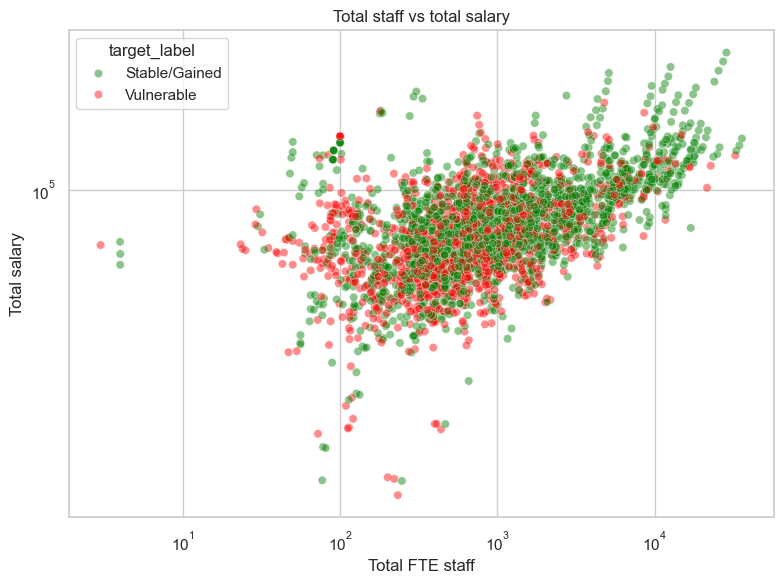

In [42]:
# 10) Scatter: total staff vs salary
plt.figure(figsize=(8, 6))
plot_df = master_panel_df.dropna(
    subset=["SFTETOTL", "SALTOTL", "TARGET_VULNERABLE_TOTAL"]
).copy()

plot_df["target_label"] = plot_df["TARGET_VULNERABLE_TOTAL"].astype(int).map(
    {0: "Stable/Gained", 1: "Vulnerable"}
)

# Clean numeric columns and create a categorical label for hue
plot_df = plot_df.copy()

plot_df["SFTETOTL"] = pd.to_numeric(plot_df["SFTETOTL"], errors="coerce")
plot_df["SALTOTL"] = pd.to_numeric(plot_df["SALTOTL"], errors="coerce")

plot_df = plot_df.dropna(subset=["SFTETOTL", "SALTOTL", "TARGET_VULNERABLE_TOTAL"]).copy()

plot_df["target_label"] = (
    plot_df["TARGET_VULNERABLE_TOTAL"].astype(int).map(
        {0: "Stable/Gained", 1: "Vulnerable"}
    )
)

sns.scatterplot(
    data=plot_df,
    x="SFTETOTL",
    y="SALTOTL",
    hue="target_label",
    alpha=0.45,
    palette=["green", "red"],
    hue_order=["Stable/Gained", "Vulnerable"],
)
plt.title("Total staff vs total salary")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Total FTE staff")
plt.ylabel("Total salary")
plt.tight_layout()
plt.show()